In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity

In [13]:
columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

df = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None,
    names=columns
)

df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [14]:
X = df[["variance"]]
X.head()

,variance
0,3.62160
1,4.54590
2,3.86600
3,3.45660
4,0.32924


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
kde = KernelDensity(
    kernel="gaussian",
    bandwidth=0.5
)

kde.fit(X_scaled)

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",0.5
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None


In [17]:
x_range = np.linspace(
    X_scaled.min(),
    X_scaled.max(),
    1000
).reshape(-1, 1)

log_density = kde.score_samples(x_range)
density = np.exp(log_density)

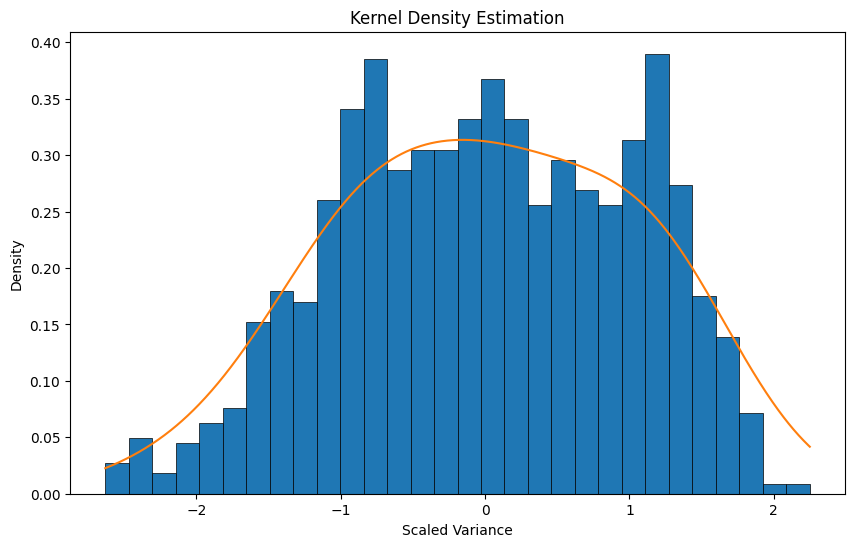

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(
    X_scaled,
    bins=30,
    density=True,
    edgecolor="black",
    linewidth=0.5
)

plt.plot(
    x_range,
    density
)

plt.title("Kernel Density Estimation")
plt.xlabel("Scaled Variance")
plt.ylabel("Density")
plt.show()

* Implemented **Unsupervised Learning — Density Estimation** using the **Kernel Density Estimation (KDE)** algorithm
* Used the **Banknote Authentication dataset**  for model training and analysis
* Performed dataset loading and preprocessing using **Pandas**
* Selected the `variance` feature for density estimation
* Applied feature scaling using **StandardScaler**
* Trained the KDE model using the **Gaussian kernel**
* Generated probability density predictions for the feature distribution
* Visualized the data distribution using **histograms and density curves** with **Matplotlib**
* Analyzed regions of high and low data concentration in the dataset
* Demonstrated the practical implementation of **density estimation in unsupervised machine learning**